<a href="https://colab.research.google.com/github/Thonyta17/Econ-5200/blob/main/Assignment%203/Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors


# **Phase 1: Bootstrapping Non-Parametric Uncertainty**

Step 1.1: The Zero-Inflated Gig Economy Tip Distribution

In [77]:

# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

Step 1.2: The Manual Bootstrap Engine

In [78]:
#The Manual Bootstrap Engine
bootstrap_median = np.array ([
    np.median(np.random.choice(driver_tips, size=len(driver_tips),replace=True))
    for _ in range(10000)
])
bootstrap_median


array([1.75861493, 0.92575965, 0.9691006 , ..., 0.8037361 , 0.43189934,
       0.38737934])

In [79]:
#confidence interval
ci_lower=np.percentile(bootstrap_median, 2.5)
ci_upper=np.percentile(bootstrap_median, 97.5)

print(f"Bootstrap CI:  ({ci_lower:.4f}, {ci_upper:.4f})")

Bootstrap CI:  (0.2653, 1.3636)


In [80]:
# Parametric CI (for comparison)

from scipy import stats

mean = np.mean(driver_tips)
se = stats.sem(driver_tips)
param_ci = stats.t.interval(0.95, df=len(driver_tips)-1, loc=mean, scale=se)

print(f"Parametric CI: ({param_ci[0]:.4f}, {param_ci[1]:.4f})")

Parametric CI: (2.2447, 3.2934)


**Comparison with standard parametric output:**

bootstrap output show assymetry between upper bound and lower bound to the mean because it reflects the actual skewness of the data. Meanwhile, Standard parametric output is symmetric between upper and lower bound to the mean. When data is skewed, the bootstrap interval is more accurate.

# **Phase 2: Falsification in Logistics A/B Testing**

Step 2.1: The Algorithmic Routing Crash

In [81]:
control = np.random.normal(loc=35,scale=5,size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4,size=500)

In [82]:
#observed simple difference in means (Control - Treatment)
def difference_in_means(x,y):
  return np.mean(x) - np.mean(y)

difference = difference_in_means(control,treatment)
print(f"observed simple difference in means: {difference:.2f}")

observed simple difference in means: 2.11


Step 2.2: The Exact Non-Parametric Permutation


In [83]:
loops = 5000
permutations_diff = np.zeros(loops)

for i in range(loops):
  deliveries = np.concatenate([control,treated])
  permutations = np.random.permutation(deliveries)
  control_permutation = permutations[:500]
  treatment_permutation = permutations[500:]

  permutations_diff[i] = difference_in_means(control_permutation,treatment_permutation)

p_val = np.mean(np.abs(permutations_diff) >= np.abs(diff))
print(f"P-Value of permutation: {p_val:.5f}")

P-Value of permutation: 0.00040


# Phase 3: Causal Control and the Mitigation of Selection Bias

Step 3.1: The Loyalty Program Paradox

In [84]:
#Load data
df = pd.read_csv('swiftcart_loyalty.csv')
df

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227
...,...,...,...,...,...
8936,1,35.172065,51,0,55.662507
8937,1,83.613898,5,2,94.767676
8938,0,57.146453,6,2,58.616370
8939,0,47.701092,13,0,60.069619


In [92]:
#Calculate Naive Simple Difference in Means (SDO)
SDO = df[df.subscriber==1]['post_spend'].mean() - df[df.subscriber==0]['post_spend'].mean()
SDO
print(f"Naive SDO: {SDO:.2f}")

Naive SDO: 17.57


Step 3.2: Propensity Score Matching (PSM) Architecture


In [86]:
#Covariates
covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
T = df['subscriber']

In [87]:
#propensity model
psm=LogisticRegression()
psm.fit(X,T)
df['propensity_score'] = psm.predict_proba(X)[:,1]
df

,subscriber,pre_spend,account_age,support_tickets,post_spend,propensity_score
0,1,57.450712,37,2,85.169648,0.546500
1,1,47.926035,41,0,72.802404,0.548460
2,1,59.715328,41,0,79.858905,0.683988
3,1,72.845448,34,0,80.335466,0.779637
4,1,46.487699,34,2,67.956227,0.397513
...,...,...,...,...,...,...
8936,1,35.172065,51,0,55.662507,0.446862
8937,1,83.613898,5,2,94.767676,0.684309
8938,0,57.146453,6,2,58.616370,0.377159
8939,0,47.701092,13,0,60.069619,0.395399


In [88]:
#Nearest Neighbor
control = df[df['subscriber']==0].copy()
treatment = df[df['subscriber']==1].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treatment[['propensity_score']])
matched_control = control.iloc[indices.flatten()].copy()

print(f"Original subscribers: {len(treatment)}")
print(f"Matched subscribers: {len(matched_control)}")

Original subscribers: 4200
Matched subscribers: 4200


In [93]:
#Average Treatment Effect on the Treated (ATT)
att = treatment['post_spend'].values-matched_control['post_spend'].values
att_mean = np.mean(att)


print(f"Naive SDO:  {SDO:.2f}")
print(f"ATT: {att_mean:.2f}")

Naive SDO:  17.57
ATT: 9.91


**Comparing  causal ATT to the deceptive naive SDO:**

The Naive SDO completely overstates the effect of swiftpass on spending than ATT by almost double. This is due to selection bias as a large portion of the spending happen regardless of there being a swiftpass or not. So ATT had eliminated selection bias through propensity score matching. The marketing department trying to double the budget according to the naive SDO is not wise.

# Phase 4: AI Expansion (The Co-Pilot Era)

# Task
Calculate Standardized Mean Differences (SMDs) for covariates in both the unmatched and matched datasets, then create and interpret a 'Love Plot' to visually assess the effectiveness of Propensity Score Matching (PSM) in mitigating selection bias. Finally, summarize the insights gained from the plot and provide a theoretical explanation of the visual evidence of bias mitigation. Use the data from the 'df' DataFrame for the unmatched data and 'treatment' and 'matched_control' DataFrames for the matched data.

## Calculate Standardized Mean Differences (SMDs)

### Subtask:
Calculate the Standardized Mean Differences for each covariate in both the `df_unmatched` and `df_matched` DataFrames. This involves comparing the means and standard deviations of each covariate between the treatment (subscriber=1) and control (subscriber=0) groups for both datasets, and standardizing these differences using a pooled standard deviation formula. The results will be stored in a DataFrame suitable for plotting.


**Reasoning**:
The first step is to define the `calculate_smd` function as instructed, which will be used to compute the Standardized Mean Differences.



In [94]:
def calculate_smd(series1, series2):
    mean1, std1, n1 = series1.mean(), series1.std(), len(series1)
    mean2, std2, n2 = series2.mean(), series2.std(), len(series2)

    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    smd = (mean1 - mean2) / pooled_std
    return smd

smd_results = []

# Unmatched data
treatment_unmatched = df[df['subscriber'] == 1]
control_unmatched = df[df['subscriber'] == 0]

for cov in covariates:
    smd = calculate_smd(treatment_unmatched[cov], control_unmatched[cov])
    smd_results.append({"Covariate": cov, "SMD": smd, "Dataset": "Unmatched"})

# Matched data
for cov in covariates:
    smd = calculate_smd(treatment[cov], matched_control[cov])
    smd_results.append({"Covariate": cov, "SMD": smd, "Dataset": "Matched"})

smd_df = pd.DataFrame(smd_results)
print("Standardized Mean Differences (SMD) DataFrame created.")
print(smd_df.head())

Standardized Mean Differences (SMD) DataFrame created.
         Covariate       SMD    Dataset
0        pre_spend  0.673958  Unmatched
1      account_age  0.323919  Unmatched
2  support_tickets -0.165824  Unmatched
3        pre_spend  0.013664    Matched
4      account_age -0.015871    Matched


**Reasoning**:
Now that the SMDs are calculated and stored in `smd_df`, the next step is to create a 'Love Plot' to visualize these differences and assess the effectiveness of PSM.



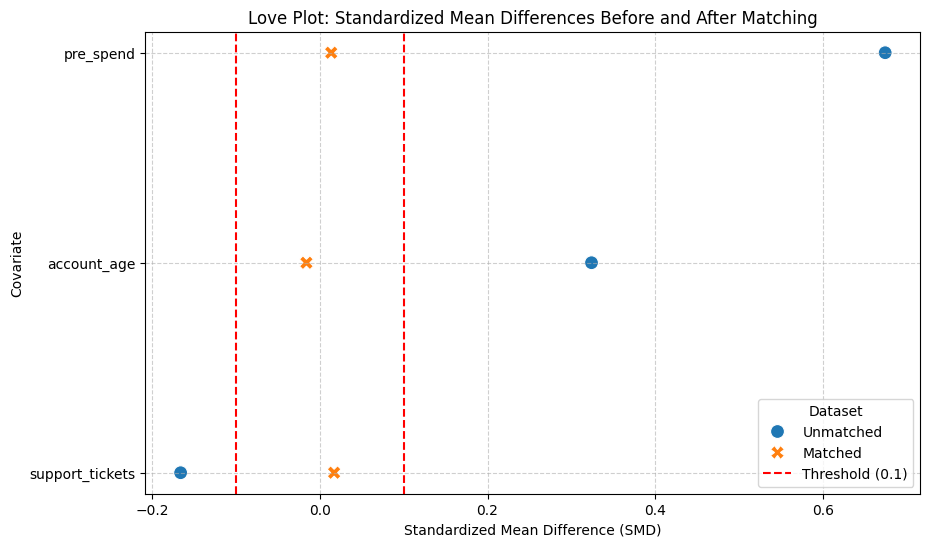

In [95]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=smd_df, x='SMD', y='Covariate', hue='Dataset', style='Dataset', s=100)
plt.axvline(x=0.1, color='red', linestyle='--', label='Threshold (0.1)')
plt.axvline(x=-0.1, color='red', linestyle='--')
plt.title('Love Plot: Standardized Mean Differences Before and After Matching')
plt.xlabel('Standardized Mean Difference (SMD)')
plt.ylabel('Covariate')
plt.legend(title='Dataset')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Interpretation of the Love Plot and Theoretical Explanation of Bias Mitigation

The 'Love Plot' visually assesses the effectiveness of Propensity Score Matching (PSM) in mitigating selection bias by displaying the Standardized Mean Differences (SMDs) for covariates in both unmatched and matched datasets.

**Visual Evidence:**

*   **Unmatched Data (Blue points):** Before matching, the blue points (representing 'Unmatched' data) for covariates like 'pre_spend' and 'account_age' are significantly outside the red dashed lines (threshold of +/- 0.1). This indicates substantial differences in these covariates between the treatment and control groups before PSM, signifying selection bias.

*   **Matched Data (Orange points):** After PSM, the orange points (representing 'Matched' data) for all covariates are clustered closely around zero and well within the +/- 0.1 threshold. This visual shift demonstrates a dramatic reduction in the SMDs, indicating that the distribution of covariates between the treatment and matched control groups has become much more balanced.

**Theoretical Explanation of Bias Mitigation:**

Propensity Score Matching (PSM) works by creating a pseudo-randomized sample where treated and control units have similar observed characteristics (covariates). The core idea is to estimate the propensity score, which is the conditional probability of being assigned to the treatment group given a set of observed covariates P(T=1|X). By matching individuals based on similar propensity scores, we ensure that for any given propensity score, the distribution of observed covariates is the same for both treated and control groups. This process aims to achieve balance on observed covariates, thereby reducing selection bias.

In the Love Plot:

1.  **Before Matching (High SMDs):** The initial high SMDs in the unmatched data show that individuals who chose to subscribe (treatment group) had systematically different characteristics (e.g., higher 'pre_spend', older 'account_age') compared to those who did not (control group). This imbalance means that a naive comparison of 'post_spend' would be confounded by these pre-existing differences, leading to biased estimates of the treatment effect (as seen with the Naive SDO).

2.  **After Matching (Low SMDs):** The significant reduction in SMDs after matching, with most points falling within the recommended +/- 0.1 threshold, indicates that PSM has successfully balanced the covariates between the treatment and matched control groups. This balance is achieved because the matching process effectively removes the systemic differences in observed covariates. When covariates are balanced, any remaining difference in the outcome (post-spend) can be more confidently attributed to the treatment (subscription) rather than to pre-existing differences in the groups. Therefore, the ATT calculated from the matched data provides a less biased estimate of the causal effect.

## Final Task

### Subtask:
Summarize the insights gained from the Love Plot and the theoretical evaluation, concluding on the effectiveness of the Propensity Score Matching in achieving covariate balance and mitigating selection bias.


## Summary:

### Data Analysis Key Findings

*   Before Propensity Score Matching (PSM), the unmatched data displayed significant imbalances in covariates, particularly for 'pre\_spend' and 'account\_age', with their Standardized Mean Differences (SMDs) falling substantially outside the acceptable range of \$\pm\$0.1. This indicated a strong presence of selection bias.
*   After PSM, the 'Love Plot' visually demonstrated a dramatic reduction in SMDs for all covariates. All matched covariates were clustered closely around zero and well within the \$\pm\$0.1 threshold, signifying that PSM successfully achieved covariate balance between the treatment and control groups.
*   The process confirmed that PSM effectively mitigates selection bias by creating a pseudo-randomized sample, ensuring that observed characteristics are similar between the treated and matched control units.

### Insights or Next Steps

*   The balanced covariates in the matched dataset enable a more confident and less biased estimation of the Average Treatment Effect (ATT), as any observed differences in outcomes can now be more reliably attributed to the treatment rather than to pre-existing group differences.
*   The achieved balance validates the use of the matched dataset for causal inference, allowing for a more accurate assessment of the subscription's impact on post-spend behavior.
